# Understanding the Heatmap

A heatmap encodes a matrix of values as a grid of coloured cells — darker or more saturated cells indicate higher (or lower) values. In EDA it is most commonly used to display **correlation matrices**, letting you survey all pairwise relationships at once.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

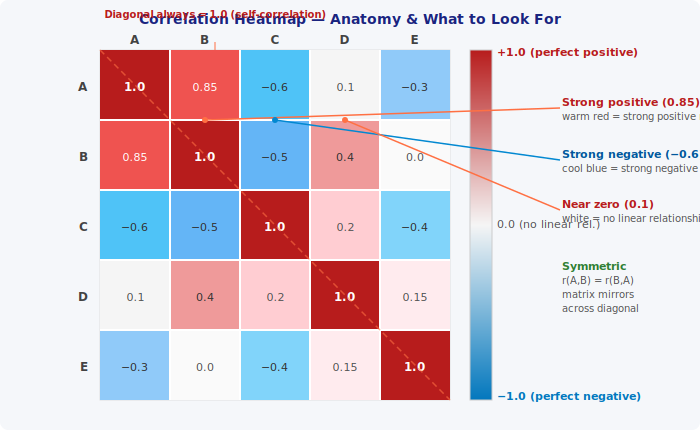

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="430"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="700" height="430" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Correlation Heatmap — Anatomy &amp; What to Look For</text>

  <!-- 5×5 grid, cells 70×70, origin at (100, 50) -->
  <!-- Features: A B C D E -->

  <!-- Row/col label backgrounds -->
  <rect x="100" y="50" width="350" height="350" fill="white" stroke="#E0E0E0" stroke-width="1"/>

  <!-- Cell colours (correlation values) -->
  <!-- Row 0 (A): A=1.0, B=0.85, C=-0.6, D=0.1, E=-0.3 -->
  <rect x="100" y="50"  width="70" height="70" fill="#B71C1C"/><!-- A,A = 1.0 -->
  <rect x="170" y="50"  width="70" height="70" fill="#EF5350"/><!-- A,B = 0.85 -->
  <rect x="240" y="50"  width="70" height="70" fill="#4FC3F7"/><!-- A,C = -0.6 -->
  <rect x="310" y="50"  width="70" height="70" fill="#F5F5F5"/><!-- A,D = 0.1 -->
  <rect x="380" y="50"  width="70" height="70" fill="#90CAF9"/><!-- A,E = -0.3 -->
  <!-- Row 1 (B) -->
  <rect x="100" y="120" width="70" height="70" fill="#EF5350"/><!-- B,A = 0.85 -->
  <rect x="170" y="120" width="70" height="70" fill="#B71C1C"/><!-- B,B = 1.0 -->
  <rect x="240" y="120" width="70" height="70" fill="#64B5F6"/><!-- B,C = -0.5 -->
  <rect x="310" y="120" width="70" height="70" fill="#EF9A9A"/><!-- B,D = 0.4 -->
  <rect x="380" y="120" width="70" height="70" fill="#FAFAFA"/><!-- B,E ≈ 0.0 -->
  <!-- Row 2 (C) -->
  <rect x="100" y="190" width="70" height="70" fill="#4FC3F7"/><!-- C,A = -0.6 -->
  <rect x="170" y="190" width="70" height="70" fill="#64B5F6"/><!-- C,B = -0.5 -->
  <rect x="240" y="190" width="70" height="70" fill="#B71C1C"/><!-- C,C = 1.0 -->
  <rect x="310" y="190" width="70" height="70" fill="#FFCDD2"/><!-- C,D = 0.2 -->
  <rect x="380" y="190" width="70" height="70" fill="#81D4FA"/><!-- C,E = -0.4 -->
  <!-- Row 3 (D) -->
  <rect x="100" y="260" width="70" height="70" fill="#F5F5F5"/><!-- D,A = 0.1 -->
  <rect x="170" y="260" width="70" height="70" fill="#EF9A9A"/><!-- D,B = 0.4 -->
  <rect x="240" y="260" width="70" height="70" fill="#FFCDD2"/><!-- D,C = 0.2 -->
  <rect x="310" y="260" width="70" height="70" fill="#B71C1C"/><!-- D,D = 1.0 -->
  <rect x="380" y="260" width="70" height="70" fill="#FFEBEE"/><!-- D,E = 0.15 -->
  <!-- Row 4 (E) -->
  <rect x="100" y="330" width="70" height="70" fill="#90CAF9"/><!-- E,A = -0.3 -->
  <rect x="170" y="330" width="70" height="70" fill="#FAFAFA"/><!-- E,B ≈ 0.0 -->
  <rect x="240" y="330" width="70" height="70" fill="#81D4FA"/><!-- E,C = -0.4 -->
  <rect x="310" y="330" width="70" height="70" fill="#FFEBEE"/><!-- E,D = 0.15 -->
  <rect x="380" y="330" width="70" height="70" fill="#B71C1C"/><!-- E,E = 1.0 -->

  <!-- Grid lines -->
  <line x1="100" y1="120" x2="450" y2="120" stroke="white" stroke-width="2"/>
  <line x1="100" y1="190" x2="450" y2="190" stroke="white" stroke-width="2"/>
  <line x1="100" y1="260" x2="450" y2="260" stroke="white" stroke-width="2"/>
  <line x1="100" y1="330" x2="450" y2="330" stroke="white" stroke-width="2"/>
  <line x1="170" y1="50" x2="170" y2="400" stroke="white" stroke-width="2"/>
  <line x1="240" y1="50" x2="240" y2="400" stroke="white" stroke-width="2"/>
  <line x1="310" y1="50" x2="310" y2="400" stroke="white" stroke-width="2"/>
  <line x1="380" y1="50" x2="380" y2="400" stroke="white" stroke-width="2"/>

  <!-- Cell annotations (r values) -->
  <text x="135" y="91"  text-anchor="middle" font-size="12" font-weight="bold" fill="white">1.0</text>
  <text x="205" y="91"  text-anchor="middle" font-size="11" fill="white">0.85</text>
  <text x="275" y="91"  text-anchor="middle" font-size="11" fill="#333">−0.6</text>
  <text x="345" y="91"  text-anchor="middle" font-size="11" fill="#555">0.1</text>
  <text x="415" y="91"  text-anchor="middle" font-size="11" fill="#333">−0.3</text>
  <text x="135" y="161" text-anchor="middle" font-size="11" fill="white">0.85</text>
  <text x="205" y="161" text-anchor="middle" font-size="12" font-weight="bold" fill="white">1.0</text>
  <text x="275" y="161" text-anchor="middle" font-size="11" fill="#333">−0.5</text>
  <text x="345" y="161" text-anchor="middle" font-size="11" fill="#333">0.4</text>
  <text x="415" y="161" text-anchor="middle" font-size="11" fill="#555">0.0</text>
  <text x="135" y="231" text-anchor="middle" font-size="11" fill="#333">−0.6</text>
  <text x="205" y="231" text-anchor="middle" font-size="11" fill="#333">−0.5</text>
  <text x="275" y="231" text-anchor="middle" font-size="12" font-weight="bold" fill="white">1.0</text>
  <text x="345" y="231" text-anchor="middle" font-size="11" fill="#555">0.2</text>
  <text x="415" y="231" text-anchor="middle" font-size="11" fill="#333">−0.4</text>
  <text x="135" y="301" text-anchor="middle" font-size="11" fill="#555">0.1</text>
  <text x="205" y="301" text-anchor="middle" font-size="11" fill="#333">0.4</text>
  <text x="275" y="301" text-anchor="middle" font-size="11" fill="#555">0.2</text>
  <text x="345" y="301" text-anchor="middle" font-size="12" font-weight="bold" fill="white">1.0</text>
  <text x="415" y="301" text-anchor="middle" font-size="11" fill="#555">0.15</text>
  <text x="135" y="371" text-anchor="middle" font-size="11" fill="#333">−0.3</text>
  <text x="205" y="371" text-anchor="middle" font-size="11" fill="#555">0.0</text>
  <text x="275" y="371" text-anchor="middle" font-size="11" fill="#333">−0.4</text>
  <text x="345" y="371" text-anchor="middle" font-size="11" fill="#555">0.15</text>
  <text x="415" y="371" text-anchor="middle" font-size="12" font-weight="bold" fill="white">1.0</text>

  <!-- Row/col labels -->
  <text x="88" y="91"  text-anchor="end" font-size="12" font-weight="bold" fill="#424242">A</text>
  <text x="88" y="161" text-anchor="end" font-size="12" font-weight="bold" fill="#424242">B</text>
  <text x="88" y="231" text-anchor="end" font-size="12" font-weight="bold" fill="#424242">C</text>
  <text x="88" y="301" text-anchor="end" font-size="12" font-weight="bold" fill="#424242">D</text>
  <text x="88" y="371" text-anchor="end" font-size="12" font-weight="bold" fill="#424242">E</text>
  <text x="135" y="44"  text-anchor="middle" font-size="12" font-weight="bold" fill="#424242">A</text>
  <text x="205" y="44"  text-anchor="middle" font-size="12" font-weight="bold" fill="#424242">B</text>
  <text x="275" y="44"  text-anchor="middle" font-size="12" font-weight="bold" fill="#424242">C</text>
  <text x="345" y="44"  text-anchor="middle" font-size="12" font-weight="bold" fill="#424242">D</text>
  <text x="415" y="44"  text-anchor="middle" font-size="12" font-weight="bold" fill="#424242">E</text>

  <!-- Colour scale bar -->
  <defs>
    <linearGradient id="corr_scale" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0%"   stop-color="#B71C1C"/>
      <stop offset="50%"  stop-color="#F5F5F5"/>
      <stop offset="100%" stop-color="#0277BD"/>
    </linearGradient>
  </defs>
  <rect x="470" y="50" width="22" height="350" fill="url(#corr_scale)" stroke="#CCC" stroke-width="1"/>
  <text x="497" y="56"  font-size="11" fill="#B71C1C" font-weight="bold">+1.0 (perfect positive)</text>
  <text x="497" y="228" font-size="11" fill="#555"> 0.0 (no linear rel.)</text>
  <text x="497" y="400" font-size="11" fill="#0277BD" font-weight="bold">−1.0 (perfect negative)</text>

  <!-- ANNOTATIONS -->

  <!-- Diagonal -->
  <line x1="100" y1="50" x2="450" y2="400" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="6,4" opacity="0.6"/>
  <line x1="215" y1="50" x2="215" y2="42" stroke="#FF7043" stroke-width="1"/>
  <text x="215" y="18" text-anchor="middle" font-size="10" font-weight="bold" fill="#B71C1C">Diagonal always = 1.0 (self-correlation)</text>

  <!-- Strong positive callout (A,B) -->
  <line x1="205" y1="120" x2="560" y2="108" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="205" cy="120" r="3" fill="#FF7043"/>
  <text x="562" y="106" font-size="11" font-weight="bold" fill="#B71C1C">Strong positive (0.85)</text>
  <text x="562" y="120" font-size="10" fill="#555">warm red = strong positive r</text>

  <!-- Strong negative callout (A,C) -->
  <line x1="275" y1="120" x2="560" y2="160" stroke="#0288D1" stroke-width="1.5"/>
  <circle cx="275" cy="120" r="3" fill="#0288D1"/>
  <text x="562" y="158" font-size="11" font-weight="bold" fill="#01579B">Strong negative (−0.6)</text>
  <text x="562" y="172" font-size="10" fill="#555">cool blue = strong negative r</text>

  <!-- Near-zero callout (A,D) -->
  <line x1="345" y1="120" x2="560" y2="210" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="345" cy="120" r="3" fill="#FF7043"/>
  <text x="562" y="208" font-size="11" font-weight="bold" fill="#B71C1C">Near zero (0.1)</text>
  <text x="562" y="222" font-size="10" fill="#555">white = no linear relationship</text>

  <!-- Symmetric note -->
  <text x="562" y="270" font-size="11" font-weight="bold" fill="#2E7D32">Symmetric</text>
  <text x="562" y="284" font-size="10" fill="#555">r(A,B) = r(B,A)</text>
  <text x="562" y="298" font-size="10" fill="#555">matrix mirrors</text>
  <text x="562" y="312" font-size="10" fill="#555">across diagonal</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Correlation Heatmap

| Feature | What it tells you |
|---|---|
| **Dark red cell** | Strong positive correlation — both features increase together |
| **Dark blue cell** | Strong negative correlation — one increases as the other decreases |
| **White / pale cell** | No linear relationship |
| **Diagonal = 1.0** | Every variable is perfectly correlated with itself |
| **Symmetric pattern** | r(A,B) always equals r(B,A) |
| **Red cluster** | Feature group — multicollinearity risk for linear models |
| **All cells pale** | Features are largely independent |

**Caution**: heatmaps only show *linear* correlation. A pair with r ≈ 0 may still have a strong non-linear dependency. Always verify surprising near-zero pairs with a scatter plot.

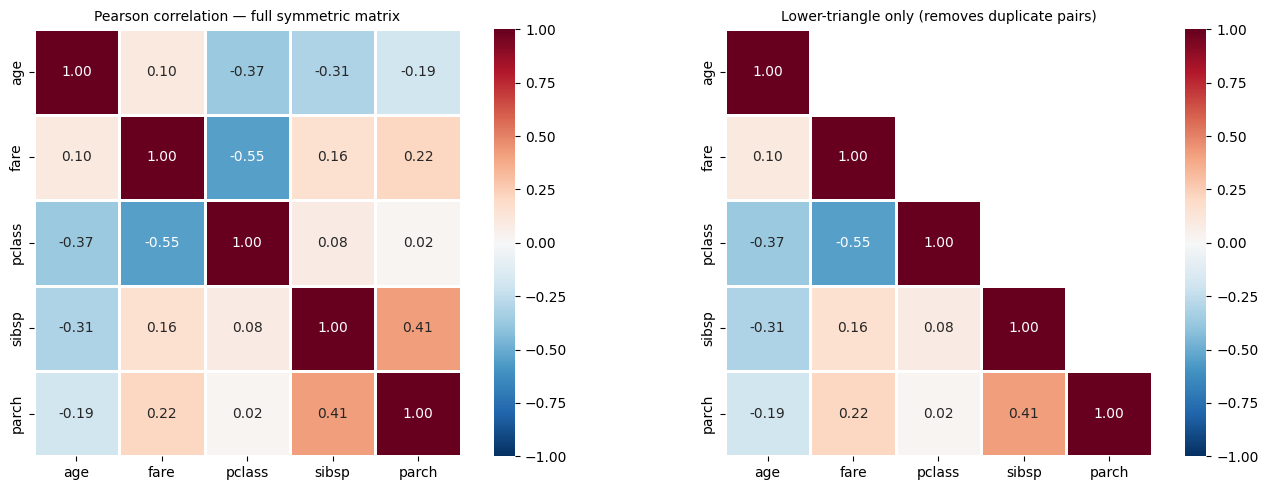

Correlation pairs ranked by |r|:
     A      B      r
  fare pclass -0.549
 parch  sibsp  0.415
   age pclass -0.369
   age  sibsp -0.308
  fare  parch  0.216
   age  parch -0.189
  fare  sibsp  0.160
   age   fare  0.096
pclass  sibsp  0.083
 parch pclass  0.018


In [3]:
df = sns.load_dataset('titanic')
num_cols = ['age', 'fare', 'pclass', 'sibsp', 'parch']
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full symmetric heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=1, ax=axes[0])
axes[0].set_title('Pearson correlation — full symmetric matrix', fontsize=10)

# Upper-triangle masked (removes redundancy)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=1, ax=axes[1])
axes[1].set_title('Lower-triangle only (removes duplicate pairs)', fontsize=10)

plt.tight_layout()
plt.show()

# Ranked correlation pairs
corr_pairs = (corr.unstack().reset_index()
              .rename(columns={'level_0':'A','level_1':'B',0:'r'}))
corr_pairs = corr_pairs[corr_pairs['A'] < corr_pairs['B']]
corr_pairs = corr_pairs.reindex(corr_pairs['r'].abs().sort_values(ascending=False).index)
print('Correlation pairs ranked by |r|:')
print(corr_pairs.round(3).to_string(index=False))

## Key Takeaways

| | |
|---|---|
| **Best for** | Surveying all pairwise linear relationships at once |
| **Red cluster** | Multicollinear group — drop redundant features for linear models |
| **Diagonal** | Always 1.0 — ignore it |
| **Lower-triangle mask** | Removes duplicate pairs, reduces clutter |
| **r = 0 ≠ no relationship** | Non-linear dependencies won't show — verify with scatter or MI |